In [1]:
import numpy as np
import matplotlib.pyplot as plt

# === PARAMETERS ===
alpha = 1000
epsilon = 3
b = 12
k = 0.3
m_ops = 0.03

In [ ]:
def optimal_profit_metrics(A, alpha=alpha, epsilon=epsilon, b=b, k=k, m_ops=m_ops):
    c = m_ops + k*(1 - float(A))
    m_profit_star = c / (epsilon - 1)
    m_total_star  = epsilon * m_profit_star
    V = alpha * (m_total_star ** (-epsilon))
    Pi_star = V * m_profit_star * b
    return {
        "A": float(A),
        "Pi*": Pi_star
    }

A0   = 0.554
A1_1 = 0.5797
A1_2 = 0.6666

# === Compute metrics ===
metrics_A0   = optimal_profit_metrics(A0)
metrics_A1_1 = optimal_profit_metrics(A1_1)
metrics_A1_2 = optimal_profit_metrics(A1_2)

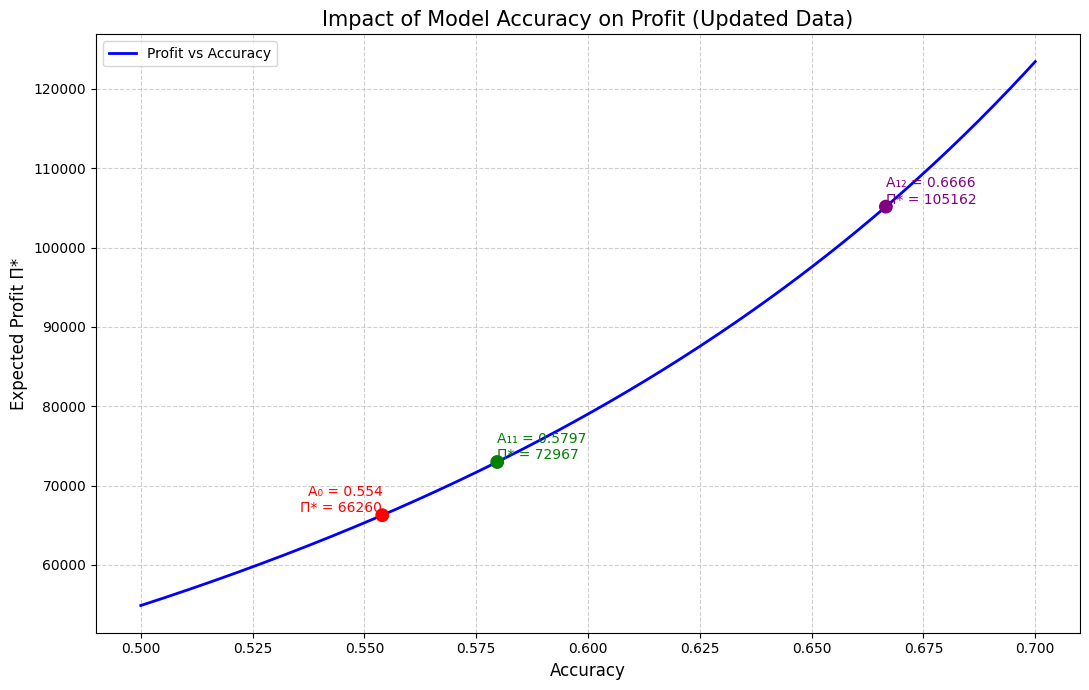

In [3]:
# === Range for visualization ===
A_values = np.linspace(0.50, 0.70, 300)
Pi_values = [optimal_profit_metrics(A)["Pi*"] for A in A_values]

# === PLOT (curve + simple points) ===
plt.figure(figsize=(11,7))
plt.plot(A_values, Pi_values, label="Profit vs Accuracy", color="blue", linewidth=2)

# Mark points (only accuracy and profit)
plt.scatter([A0, A1_1, A1_2],
            [metrics_A0["Pi*"], metrics_A1_1["Pi*"], metrics_A1_2["Pi*"]],
            color=["red","green","purple"], zorder=5, s=80)

# Annotate points with just Accuracy and Profit
plt.text(A0, metrics_A0["Pi*"], f"A₀ = {A0:.3f}\nΠ* = {metrics_A0['Pi*']:.0f}",
         color="red", ha="right", va="bottom")
plt.text(A1_1, metrics_A1_1["Pi*"], f"A₁₁ = {A1_1:.4f}\nΠ* = {metrics_A1_1['Pi*']:.0f}",
         color="green", ha="left", va="bottom")
plt.text(A1_2, metrics_A1_2["Pi*"], f"A₁₂ = {A1_2:.4f}\nΠ* = {metrics_A1_2['Pi*']:.0f}",
         color="purple", ha="left", va="bottom")

plt.xlabel("Accuracy", fontsize=12)
plt.ylabel("Expected Profit Π*", fontsize=12)
plt.title("Impact of Model Accuracy on Profit (Updated Data)", fontsize=15)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()
